# Análise Exploratória dos Exoplanetas

Este notebook realiza uma análise exploratória inicial do dataset `data/raw/exoplanets.csv`, coletado do NASA Exoplanet Archive. O objetivo é entender a estrutura dos dados, avaliar valores ausentes, observar distribuições das variáveis principais e levantar primeiras hipóteses sobre propriedades físicas e orbitais dos exoplanetas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Carregamento dos dados

In [3]:
diretorio_dados = Path("../data/raw")
caminho_csv = diretorio_dados / "exoplanets.csv"

df = pd.read_csv(caminho_csv)
df.head()

,pl_name,pl_rade,pl_bmasse,pl_orbper,st_teff
0,WASP-133 b,14.1848,NaN,2.1765,5646.0000
1,TOI-4010 b,3.0200,11.0000,1.3483,4960.0000
2,Kepler-314 c,2.7500,NaN,5.9604,5421.0000
3,TOI-2384 b,11.4892,624.8506,2.1357,3943.0000
4,K2-321 b,1.9500,NaN,2.2980,3855.0000


In [4]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
df.info()

Linhas: 25161
Colunas: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25161 entries, 0 to 25160
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pl_name    25161 non-null  object 
 1   pl_rade    25161 non-null  float64
 2   pl_bmasse  3306 non-null   float64
 3   pl_orbper  25161 non-null  float64
 4   st_teff    24046 non-null  float64
dtypes: float64(4), object(1)
memory usage: 983.0+ KB


## 2. Dicionário das colunas

| Coluna | Significado | Unidade aproximada |
| --- | --- | --- |
| `pl_name` | Nome do exoplaneta | Texto |
| `pl_rade` | Raio do planeta | Raios terrestres |
| `pl_bmasse` | Massa do planeta | Massas terrestres |
| `pl_orbper` | Per?odo orbital | Dias |
| `st_teff` | Temperatura efetiva da estrela | Kelvin |

## 3. Qualidade dos dados

Nesta etapa verificamos valores ausentes, duplicatas e a consistência básica das colunas numéricas.

In [5]:
valores_ausentes = (
    df.isna()
    .sum()
    .to_frame("ausentes")
    .assign(percentual=lambda tabela: tabela["ausentes"] / len(df) * 100)
    .sort_values("percentual", ascending=False)
)

valores_ausentes

,ausentes,percentual
pl_bmasse,21855,86.8606
st_teff,1115,4.4315
pl_name,0,0.0000
pl_rade,0,0.0000
pl_orbper,0,0.0000


In [6]:
duplicados_nome = df["pl_name"].duplicated().sum()
print(f"Nomes de planetas duplicados: {duplicados_nome}")

if duplicados_nome > 0:
    display(df[df["pl_name"].duplicated(keep=False)].sort_values("pl_name").head(20))

Nomes de planetas duplicados: 20463


,pl_name,pl_rade,pl_bmasse,pl_orbper,st_teff
2921,55 Cnc e,1.9470,8.5900,0.7365,NaN
1821,55 Cnc e,1.9100,8.0800,0.7365,5250.0000
2971,55 Cnc e,2.0800,7.8100,0.7365,5234.0000
3529,55 Cnc e,1.8970,7.7400,0.7370,5172.0000
2151,55 Cnc e,2.0000,8.6300,0.7365,NaN
446,55 Cnc e,1.8560,NaN,0.7365,5272.0000
912,55 Cnc e,2.1730,8.3700,0.7365,5250.0000
935,55 Cnc e,2.0231,NaN,0.7365,5250.0000
998,55 Cnc e,1.8750,7.9900,0.7365,5172.0000
3964,AU Mic b,4.0700,17.0000,8.4630,3700.0000


In [7]:
colunas_numericas = ["pl_rade", "pl_bmasse", "pl_orbper", "st_teff"]

df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_rade,25161.0000,5.6370,74.4885,0.2700,1.5600,2.3000,3.3319,4282.9800
pl_bmasse,3306.0000,344.4627,895.6702,0.0650,8.7925,88.1976,336.8998,25426.4000
pl_orbper,25161.0000,16799.1958,2535353.1443,0.1120,4.1783,9.3041,21.0575,402000000.0000
st_teff,24046.0000,5467.7513,801.8309,2320.0000,5125.2500,5646.0000,5986.0000,27730.0000


## 4. Distribuições das variáveis numéricas

Como dados astronômicos costumam ter valores muito extremos, os gráficos abaixo usam escala logarítmica em algumas variáveis para facilitar a leitura.

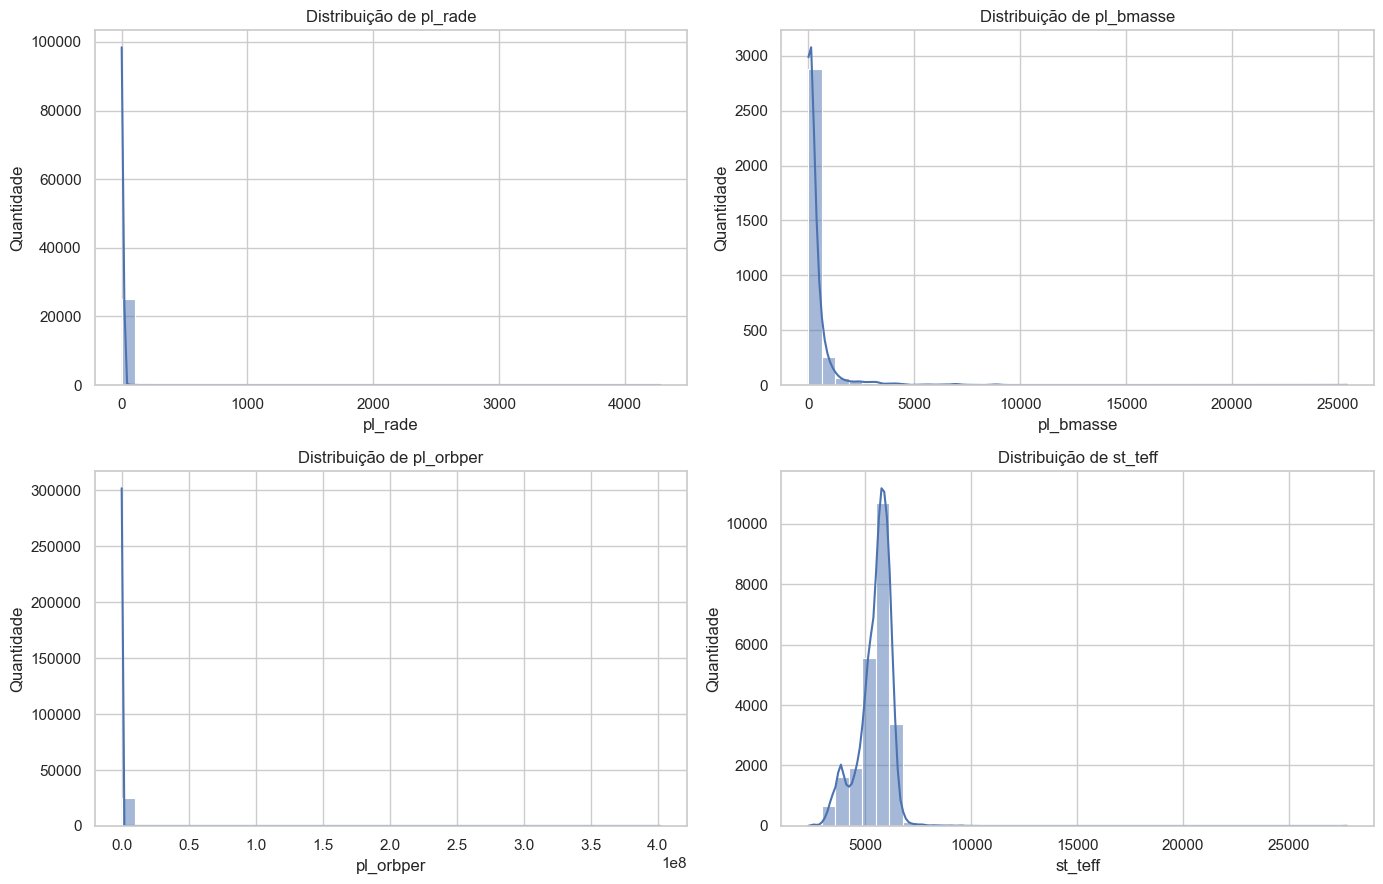

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, coluna in zip(axes, colunas_numericas):
    dados = df[coluna].dropna()
    sns.histplot(dados, bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribuição de {coluna}")
    ax.set_xlabel(coluna)
    ax.set_ylabel("Quantidade")

plt.tight_layout()

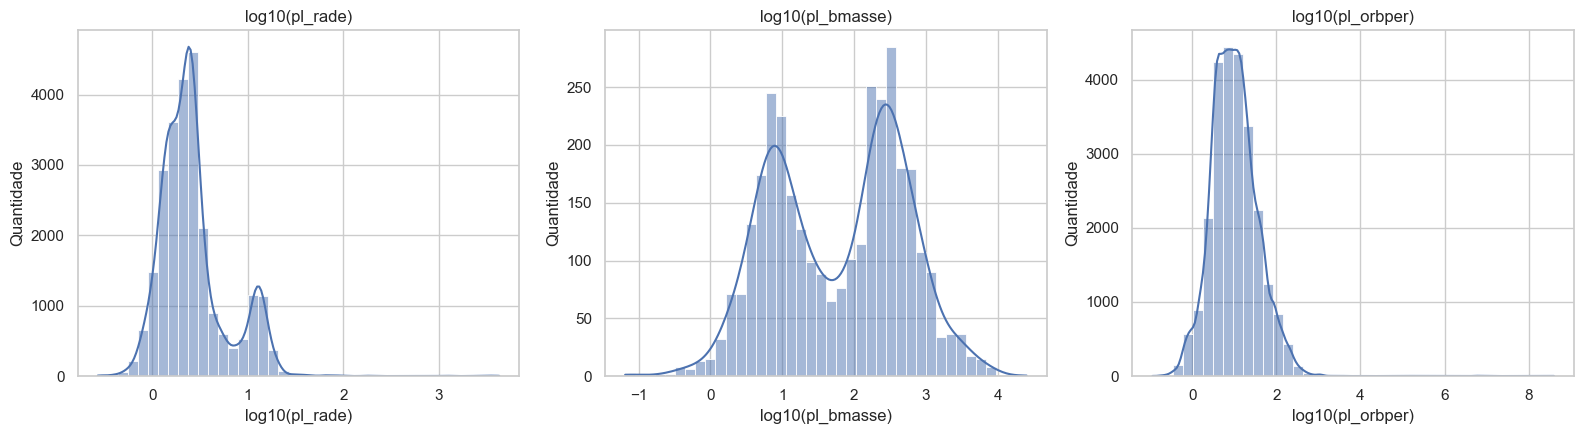

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, coluna in zip(axes, ["pl_rade", "pl_bmasse", "pl_orbper"]):
    dados = df.loc[df[coluna] > 0, coluna].dropna()
    sns.histplot(np.log10(dados), bins=40, kde=True, ax=ax)
    ax.set_title(f"log10({coluna})")
    ax.set_xlabel(f"log10({coluna})")
    ax.set_ylabel("Quantidade")

plt.tight_layout()

## 5. Relações entre variáveis

Aqui analisamos relações entre raio, massa, período orbital e temperatura da estrela. A escala logarítmica ajuda a visualizar planetas pequenos e gigantes no mesmo gráfico.

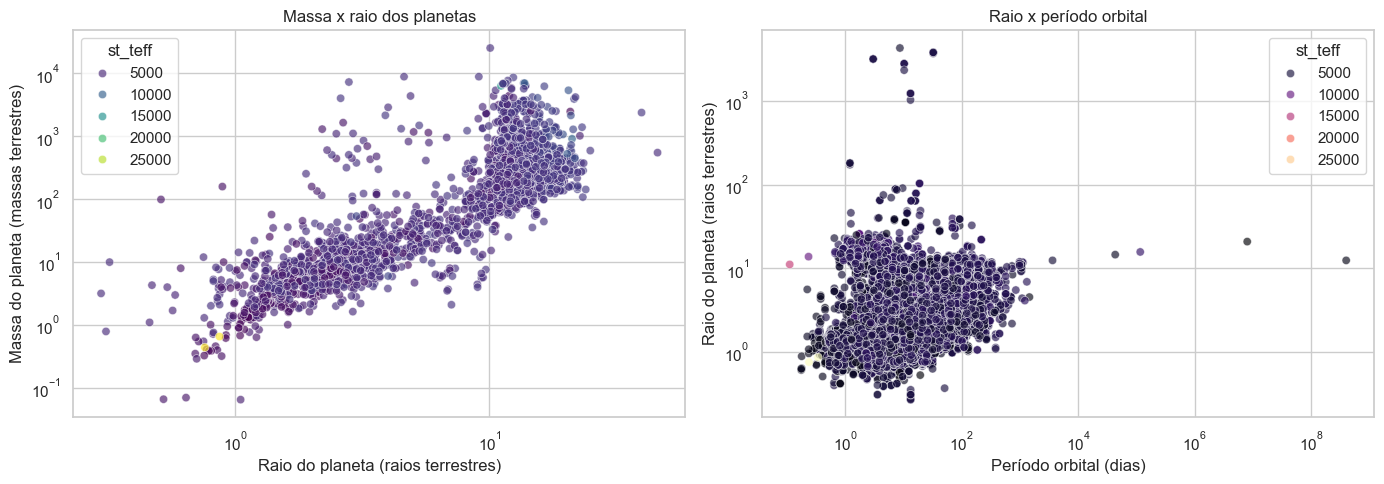

In [12]:
df_plot = df.copy()
for coluna in ["pl_rade", "pl_bmasse", "pl_orbper"]:
    df_plot = df_plot[df_plot[coluna].isna() | (df_plot[coluna] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_plot,
    x="pl_rade",
    y="pl_bmasse",
    hue="st_teff",
    palette="viridis",
    alpha=0.65,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Massa x raio dos planetas")
axes[0].set_xlabel("Raio do planeta (raios terrestres)")
axes[0].set_ylabel("Massa do planeta (massas terrestres)")

sns.scatterplot(
    data=df_plot,
    x="pl_orbper",
    y="pl_rade",
    hue="st_teff",
    palette="magma",
    alpha=0.65,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Raio x período orbital")
axes[1].set_xlabel("Período orbital (dias)")
axes[1].set_ylabel("Raio do planeta (raios terrestres)")

plt.tight_layout()

,pl_rade,pl_bmasse,pl_orbper,st_teff
pl_rade,1.0000,0.2902,0.0006,0.0093
pl_bmasse,0.2902,1.0000,0.0354,0.2006
pl_orbper,0.0006,0.0354,1.0000,-0.0171
st_teff,0.0093,0.2006,-0.0171,1.0000


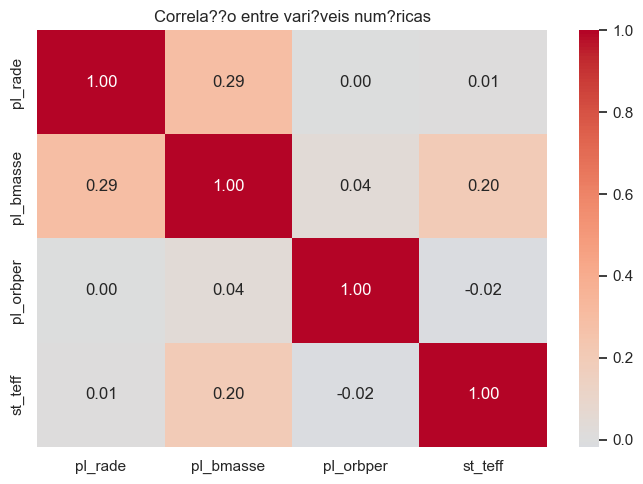

In [13]:
correlacao = df[colunas_numericas].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correla??o entre vari?veis num?ricas")
plt.tight_layout()

correlacao

## 6. Classificação simples por tamanho

A classificação abaixo é apenas exploratória e usa faixas aproximadas baseadas no raio do planeta em raios terrestres.

In [14]:
bins = [0, 1.25, 2, 6, 15, np.inf]
labels = ["Rochoso/Terrestre", "Super-Terra", "Sub-Netuno/Netuno", "Gigante gasoso", "Muito grande"]

df_tamanhos = df.copy()
df_tamanhos["classe_tamanho"] = pd.cut(df_tamanhos["pl_rade"], bins=bins, labels=labels)

contagem_classes = df_tamanhos["classe_tamanho"].value_counts().reindex(labels)
contagem_classes

classe_tamanho
Rochoso/Terrestre     3246
Super-Terra           6857
Sub-Netuno/Netuno    11209
Gigante gasoso        2997
Muito grande           852
Name: count, dtype: int64

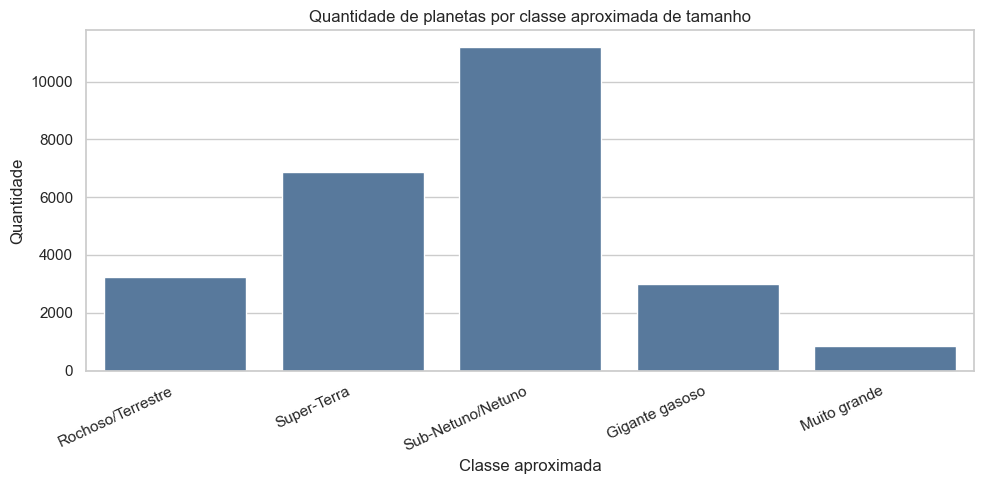

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x=contagem_classes.index, y=contagem_classes.values, color="#4C78A8")
plt.title("Quantidade de planetas por classe aproximada de tamanho")
plt.xlabel("Classe aproximada")
plt.ylabel("Quantidade")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

## 7. Valores extremos

Os maiores valores podem indicar planetas realmente extremos, objetos com classificação diferente, incertezas observacionais ou registros que exigem validação antes de análises mais conclusivas.

In [16]:
display(df.nlargest(10, "pl_rade")[["pl_name", "pl_rade", "pl_bmasse", "pl_orbper", "st_teff"]])
display(df.nlargest(10, "pl_bmasse")[["pl_name", "pl_rade", "pl_bmasse", "pl_orbper", "st_teff"]])
display(df.nlargest(10, "pl_orbper")[["pl_name", "pl_rade", "pl_bmasse", "pl_orbper", "st_teff"]])

,pl_name,pl_rade,pl_bmasse,pl_orbper,st_teff
2308,Kepler-1999 b,4282.9800,NaN,8.7393,4403.0000
13726,Kepler-230 b,3791.0500,NaN,32.6288,5588.0000
15022,Kepler-230 b,3791.0500,NaN,32.6288,5588.0000
18160,Kepler-230 b,3791.0500,NaN,32.6288,5588.0000
14185,Kepler-230 b,3690.8890,NaN,32.6288,5253.0000
7505,Kepler-1946 b,3163.5400,NaN,3.0352,5505.0000
7591,Kepler-1946 b,3163.5400,NaN,3.0352,5505.0000
13546,Kepler-1946 b,3163.5400,NaN,3.0352,5505.0000
7034,Kepler-29 b,2783.7000,NaN,10.3393,5716.0000
7073,Kepler-29 b,2783.7000,NaN,10.3393,5716.0000


,pl_name,pl_rade,pl_bmasse,pl_orbper,st_teff
10896,PH2 b,10.0881,25426.4000,282.5250,5629.0000
486,HD 206893 b,14.0112,8899.1954,9350.0000,NaN
5725,TOI-5422 b,9.1017,8899.1954,5.3772,5820.0000
22582,Kepler-47 c,4.6200,8899.0000,303.1370,5636.0000
1586,KELT-1 b,12.4420,8654.1500,1.2175,6516.0000
1741,TOI-5882 b,11.8367,7720.0520,7.1490,6060.0000
24272,KOI-2513.01,2.8022,7310.0534,19.0055,5900.0000
12571,TOI-1994 b,13.6750,7024.0078,4.0337,7700.0000
13871,ZTF J1230-2655 b,13.7870,7024.0078,0.2360,10000.0000
3267,TOI-5882 b,11.4668,6995.4032,7.1490,5920.0000


,pl_name,pl_rade,pl_bmasse,pl_orbper,st_teff
2003,COCONUTS-2 b,12.4420,2002.3190,402000000.0000,3406.0000
10636,CFHTWIR-Oph 98 b,20.8487,2479.0616,8040000.0000,2320.0000
20132,VHS J125601.92-125723.9 b,13.6750,5085.2545,5800000.0000,NaN
24456,VHS J125601.92-125723.9 b,14.5717,3813.9409,5800000.0000,NaN
5812,HR 8799 b,13.0000,2000.0000,170000.0000,NaN
1775,HD 143811 AB b,15.6926,1938.7533,117000.0000,6791.0000
13376,HR 8799 c,13.0000,3000.0000,69000.0000,NaN
9409,PDS 70 b,14.5717,2542.6400,43500.0000,3972.0000
13191,HR 8799 d,13.0000,3000.0000,37000.0000,NaN
486,HD 206893 b,14.0112,8899.1954,9350.0000,NaN


## 8. Candidatos para investigação de habitabilidade

Esta é uma triagem simples, não uma conclusão de habitabilidade. Foram selecionados planetas com raio próximo ao terrestre, estrela com temperatura semelhante à de estrelas mais favoráveis à vida como conhecemos e período orbital intermediário.

In [17]:
candidatos_habitabilidade = df[
    df["pl_rade"].between(0.8, 1.8)
    & df["st_teff"].between(4500, 6500)
    & df["pl_orbper"].between(50, 500)
].copy()

candidatos_habitabilidade = candidatos_habitabilidade.sort_values(["pl_rade", "pl_orbper"])

print(f"Candidatos encontrados: {len(candidatos_habitabilidade)}")
candidatos_habitabilidade[["pl_name", "pl_rade", "pl_bmasse", "pl_orbper", "st_teff"]].head(30)

Candidatos encontrados: 222


,pl_name,pl_rade,pl_bmasse,pl_orbper,st_teff
1891,Kepler-409 b,0.9800,NaN,68.9586,5460.0000
3191,Kepler-409 b,0.9800,NaN,68.9586,5460.0000
3418,Kepler-409 b,0.9800,NaN,68.9586,5499.0000
3757,Kepler-409 b,0.9800,NaN,68.9586,5460.0000
1561,Kepler-409 b,0.9810,NaN,68.9586,5416.0000
22643,Kepler-1633 b,1.0600,NaN,186.4043,6351.0000
24454,Kepler-1633 b,1.0600,NaN,186.4043,6351.0000
16262,Kepler-367 c,1.0800,NaN,53.5782,4739.0000
16346,Kepler-1605 b,1.0800,NaN,85.7565,5280.0000
18266,Kepler-130 d,1.0900,NaN,87.5187,5873.0000


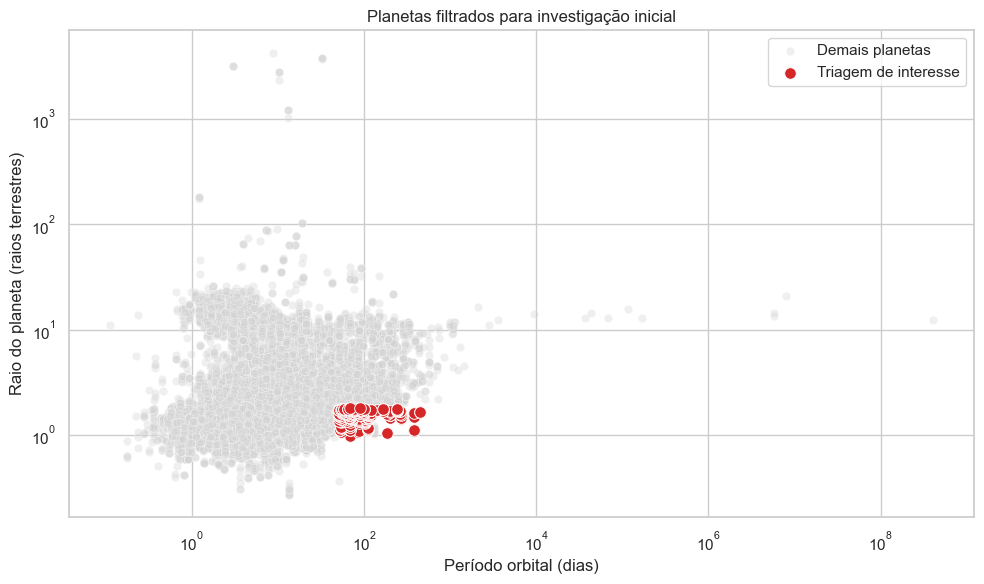

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="pl_orbper",
    y="pl_rade",
    color="lightgray",
    alpha=0.35,
    label="Demais planetas",
)
sns.scatterplot(
    data=candidatos_habitabilidade,
    x="pl_orbper",
    y="pl_rade",
    color="#D62728",
    s=70,
    label="Triagem de interesse",
)
plt.xscale("log")
plt.yscale("log")
plt.title("Planetas filtrados para investigação inicial")
plt.xlabel("Período orbital (dias)")
plt.ylabel("Raio do planeta (raios terrestres)")
plt.legend()
plt.tight_layout()

## 9. Principais observações iniciais

- O dataset possui muitas medições de raio e per?odo orbital, mas a coluna de massa tem muitos valores ausentes.
- As distribuições de raio, massa e período orbital são assimétricas e contém valores extremos.
- Escalas logarítmicas são mais adequadas para comparar planetas muito diferentes entre si.
- A an?lise de habitabilidade precisa de mais variáveis, como luminosidade da estrela, fluxo recebido pelo planeta, distância orbital e incertezas das medições.
- As próximas etapas recomendadas são limpeza de outliers, criação de um dataset tratado em `data/processed` e aprofundamento das visualizações.